# KNN from scratch

El objetivo de este notebook es comprender la intuición, las operaciones matemáticas y el comportamiento interno de KNN desde cero.

## 1. Importación de Librerías

Comenzamos cargando las librerías necesarias. Fíjate en cómo cada una tiene un propósito específico en nuestro flujo de trabajo:

In [168]:
import numpy as np
import pandas as pd

from sklearn.metrics import pairwise_distances
from sklearn.neighbors import KNeighborsClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

from sklearn.base import BaseEstimator, ClassifierMixin

np.random.seed(42)

## 2. Generación de Datos Sintéticos (Espacio de Características 2D)

Para poder **visualizar en un plano cartesiano (2D)** cómo razona KNN, crearemos un conjunto de datos sintético de dos clases (Clase 0 y Clase 1) con 2 características (`feature1` y `feature2`).

In [169]:
# Número de muestras por clase
n_samples_per_class = 150

# Feature 1 → escala pequeña
sigma_x1 = 0.10

# Feature 2 → escala mucho mayor
sigma_x2 = 1.50

# Clase 0
X1_clase0 = np.random.normal(loc=1.00, scale=sigma_x1, size=n_samples_per_class)
X2_clase0 = np.random.normal(loc=6.5, scale=sigma_x2, size=n_samples_per_class)
y_clase0 = np.zeros(n_samples_per_class, dtype=int)

# Clase 1
X1_clase1 = np.random.normal(loc=1.25, scale=sigma_x1, size=n_samples_per_class)
X2_clase1 = np.random.normal(loc=7.5, scale=sigma_x2, size=n_samples_per_class)
y_clase1 = np.ones(n_samples_per_class, dtype=int)

# Combinar datos
X1 = np.concatenate([X1_clase0, X1_clase1])
X2 = np.concatenate([X2_clase0, X2_clase1])
y = np.concatenate([y_clase0, y_clase1])

En este caso se podría haber tomado simplemente la información previa a la creación del DataFrame en formato array. Sin embargo, se optará por seguir con el DataFrame para facilitar la asociación del conocimiento con el común de las clases, donde se trabaja con el formato tabular de los DataFrames.

In [170]:
# Crear DataFrame Tabular (formato común de trabajo)
df_A = pd.DataFrame({
    'feature1': X1,
    'feature2': X2,
    'clase': y
})

print("Primeras 5 filas del conjunto de datos:")
display(df_A.head())

Primeras 5 filas del conjunto de datos:


,feature1,feature2,clase
0,1.049671,6.875739,0
1,0.986174,7.019672,0
2,1.064769,5.479963,0
3,1.152303,6.848381,0
4,0.976585,6.939609,0


## 3. Preprocesamiento

### 3.1 Separación de Variables (`X` e `y`)

In [171]:
X = df_A[['feature1', 'feature2']]
y = df_A['clase']

### Separación en train - test:

In [172]:
# División Train / Test estratificada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Muestras de entrenamiento: {len(X_train)} | Muestras de prueba: {len(X_test)}")

Muestras de entrenamiento: 240 | Muestras de prueba: 60


### 3.3 EL PASO ESENCIAL: El Escalado es OBLIGATORIO en KNN

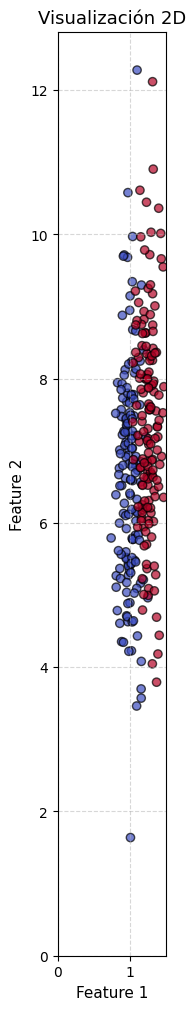

In [173]:
fig, ax = plt.subplots(figsize=(12, 12))

ax.scatter(
    df_A['feature1'], df_A['feature2'],
    c=df_A['clase'], cmap='coolwarm',
    alpha=0.7, edgecolors='k'
)

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

ax.set_aspect('equal', adjustable='box')

ax.set_title("Visualización 2D", fontsize=13)
ax.set_xlabel("Feature 1", fontsize=11)
ax.set_ylabel("Feature 2", fontsize=11)

ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

Instancia de StandardScaler:

In [174]:
sc = StandardScaler()

Entrenamiento de nuestra instancia de StandardScaler:

In [175]:
sc.fit(X_train)

StandardScaler()

Transformación de subconjuntos X de entrenamiento y testeo:

In [176]:
X_train_scaled = sc.transform(X_train)

In [177]:
X_test_scaled = sc.transform(X_test)

Transformando en formato DataFrame:

In [178]:
X_train_scaled = pd.DataFrame(data=X_train_scaled, columns=sc.get_feature_names_out(), index=X_train.index)

In [179]:
X_test_scaled = pd.DataFrame(data=X_test_scaled, columns=sc.get_feature_names_out(), index=X_test.index)

Como se puede observar, la columna 1 está en una escala bastante más acotada que la columna 2. Esto nos lleva a entender cómo los K vecinos se verán influenciados por esta variable, donde los puntos tenderán a estar más cerca, aunque proporcionalmente respecto a la columna 2 no lo estén. Esto nos recuerda la importancia del escalado.

### 3.2 Visualizando los Datos desde 'Los Ojos de KNN'

A este punto, es importante tener claro que los subconjuntos de datos de entrenamiento y testeo son filas distintas, con distintos valores en cada feature. Esto se puede observar desde 'los ojos de KNN' al plotear en 2D ambos subconjuntos. Plotearemos los datos de entrenamiento (Círculos) y Test (x) en el plano cartesiano:

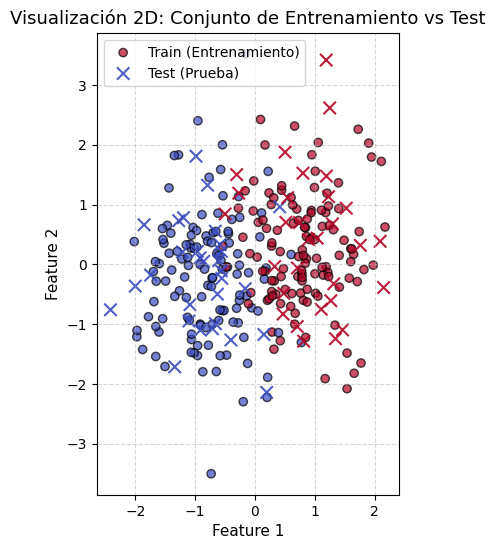

In [180]:
fig, ax = plt.subplots(figsize=(12, 6))

# Puntos de Entrenamiento
ax.scatter(
    X_train_scaled['feature1'], X_train_scaled['feature2'],
    c=y_train, cmap='coolwarm', alpha=0.7, edgecolors='k', label='Train (Entrenamiento)'
)

# Puntos de Test
ax.scatter(
    X_test_scaled['feature1'], X_test_scaled['feature2'],
    c=y_test, cmap='coolwarm', marker='x', s=80, alpha=0.9, label='Test (Prueba)'
)

ax.set_aspect('equal', adjustable='box')

ax.set_title("Visualización 2D: Conjunto de Entrenamiento vs Test", fontsize=13)
ax.set_xlabel("Feature 1", fontsize=11)
ax.set_ylabel("Feature 2", fontsize=11)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

## 4. KNN 'Bajo el Capó': Operaciones Paso a Paso

Recordemos el ciclo de vida de **KNN (K-Nearest Neighbors)**:

1. **Hiperparámetro $K$:** Número de vecinos que consultaremos para decidir la etiqueta. Usar un número **impar** ($K=3, 5, 7$) en clasificación binaria evita empates.
2. **Entrenamiento ('Lazy Learner'):** KNN no aprende fórmulas ni coeficientes. Durante el `fit()`, **solo memoriza los datos** $X_{train}$ e $y_{train}$.
3. **Predicción (Cálculo real):** Cuando llega un nuevo punto $x_{nuevo}$:
   - Se calcula la **distancia euclidiana** respecto a *todas* las muestras de $X_{train}$.
   - Se ordenan de menor a mayor distancia.
   - Se seleccionan las $K$ muestras más cercanas.
   - **Votación:** En clasificación se toma la **moda** (clase más frecuente); en regresión, el **promedio**.

### Pseudo instancia

> En este caso desarrollaremos paso a paso el algoritmo y, para simplificar su comprensión, el código se desarrollará línea a línea (sin uso de clases ni POO). Por lo tanto, en este paso definiremos únicamente el hiperparámetro principal `K`.

In [181]:
# 1. Definimos K (número de vecinos)
k = 5

### Entrenamiento:

> Como vimos, en este paso KNN solo guarda los datos, por lo que se continuará a la predicción.

### Predicción

Elegimos la fila sobre la que se desea predecir:

In [182]:
# 2. Seleccionamos la primera fila de X_test_scaled sobre la cual predeciremos
fila1 = X_test_scaled.iloc[[0]]

print(f"Coordenadas de la muestra test [0]:\n{fila1.to_dict('records')[0]}\n")

Coordenadas de la muestra test [0]:
{'feature1': 0.19507535595938108, 'feature2': -2.140574633014026}



Calculamos las distancias con respecto a cada fila de X_train_scaled, estableciendo la métrica de distancia:

In [183]:
# 3. Calculamos la distancia euclidiana hacia TODAS las filas de X_train_scaled
distancias = pairwise_distances(fila1, X_train_scaled, metric="euclidean")[0]

Encontramos las K filas vecinas de X_train_scaled:

In [184]:
# 4. Obtenemos los índices de los K vecinos con menor distancia (orden ascendente)
indices_vecinos = distancias.argsort()[:k]

print(f"Distancias a los {k} vecinos más cercanos:\n{distancias[indices_vecinos].round(4)}")

Distancias a los 5 vecinos más cercanos:
[0.0843 0.2526 0.4211 0.58   0.7321]


Obtenemos las etiquetas (en este caso clases - categorías) de los vecinos:

In [185]:
# 5. Extraemos las clases reales de esos K vecinos
y_vecinos = y_train.iloc[indices_vecinos]

print(f"Clases de los {k} vecinos más cercanos:\n{y_vecinos.values}")

Clases de los 5 vecinos más cercanos:
[0 0 0 0 1]


Se hace la votación; en este caso, como es un problema de clasificación, se toma la moda de la etiqueta asociada a los K vecinos (en caso de regresión se toma la media):

In [186]:
# 6. Realizamos la votación por mayoría (Moda)
prediccion_final = y_vecinos.mode()[0]

print(f"Votación resultante (Moda): Clase {prediccion_final}")
print(f"Etiqueta real de la muestra: Clase {y_test.iloc[0]}")

Votación resultante (Moda): Clase 0
Etiqueta real de la muestra: Clase 0


## 5. Empaquetado del Algoritmo en una Clase Estimadora (`MyKNN`)

Para visualizar las **fronteras de decisión**, empaquetamos nuestra lógica paso a paso dentro de una clase compatible con Scikit-Learn (`BaseEstimator`, `ClassifierMixin`).

In [187]:
class MyKNN(BaseEstimator, ClassifierMixin):
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        # Memorización de datos de entrenamiento en formato NumPy
        self.X_train_scaled_ = np.asarray(X)
        self.y_train_ = np.asarray(y).ravel()
        self.classes_ = np.unique(self.y_train_)
        return self

    def predict(self, X):
        X = np.asarray(X)
        # Matriz de distancias: (N_muestras_test, N_muestras_train)
        distancias_matriz = pairwise_distances(X, self.X_train_scaled_, metric="euclidean")

        predicciones = []
        for dist in distancias_matriz:
            # Índices de los K vecinos más cercanos
            indices_vecinos = dist.argsort()[:self.k]
            y_vecinos = self.y_train_[indices_vecinos]

            # Votación por frecuencia (argmax del conteo de enteros)
            prediccion = np.bincount(y_vecinos).argmax()
            predicciones.append(prediccion)

        return np.array(predicciones)

## 6. Comprendiendo la Frontera de Decisión: Ajuste Local vs. Ajuste Global

El hiperparámetro $K$ controla el equilibrio entre **Overfitting** (Sobreajuste) y **Underfitting** (Subajuste):

* **$K = 1$ (Ajuste Extremadamente Local):** El modelo copia al detalle el ruido del conjunto de entrenamiento (**Overfitting** / Alta Varianza). La frontera es sinuosa e irregular.
* **$K = 5$ (Ajuste Balanceado):** Suaviza el ruido y captura la tendencia subyacente.
* **$K = N_{train}$ (Ajuste Extremadamente Global):** Considera a todos los datos del dataset. Predice siempre la clase mayoritaria (**Underfitting** / Alto Sesgo).

Una vez definida la distancia y elegido K, queda definida la regla de predicción de KNN. Cuando llega un nuevo punto, KNN busca sus K vecinos más cercanos y, a partir de sus etiquetas, determina la predicción.
La frontera de decisión no se calcula previamente ni KNN etiqueta todo el espacio. Queda implícitamente determinada por las muestras de entrenamiento, la distancia y K. Para visualizarla, podemos aplicar la regla de KNN a muchos puntos de una cuadrícula y colorearlos según la categoría que KNN predeciría en cada lugar.

En este caso se utilizará la clase de scikit-learn `DecisionBoundaryDisplay`, la cual simplifica este proceso visual. Los puntos superpuestos sobre esta frontera corresponderán, en primer lugar, a los mismos datos de entrenamiento y, en segundo lugar, a los datos de prueba (test), permitiendo así observar el sobreajuste o subajuste según corresponda.

/tmp/ipykernel_903/3331856425.py:25: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/tmp/ipykernel_903/3331856425.py:25: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/tmp/ipykernel_903/3331856425.py:25: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


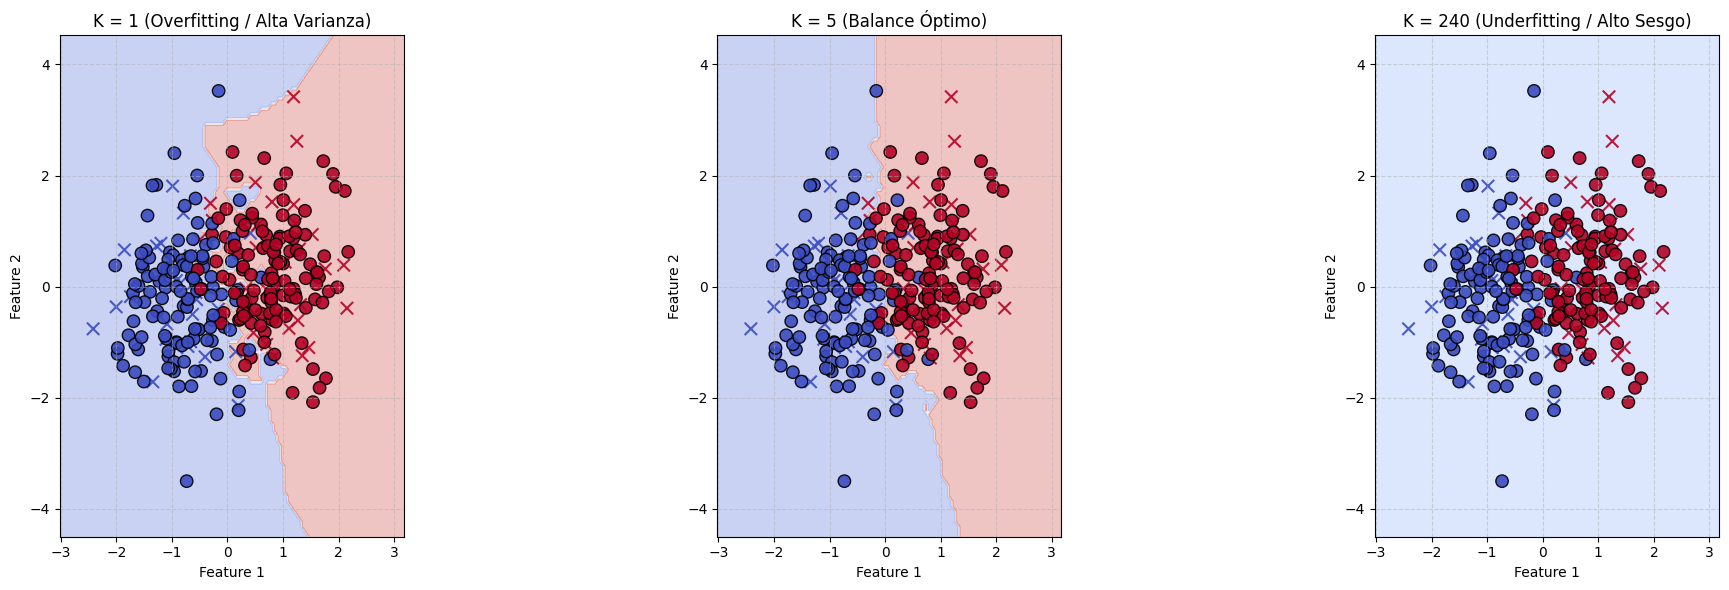

In [188]:
k_values = [1, 5, len(X_train_scaled)]
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

titles = [
    "K = 1 (Overfitting / Alta Varianza)",
    "K = 5 (Balance Óptimo)",
    f"K = {len(X_train_scaled)} (Underfitting / Alto Sesgo)"
]

for ax, k_val, title in zip(axes, k_values, titles):
    model = MyKNN(k=k_val)
    model.fit(X_train_scaled, y_train)

    # Dibujar la frontera de decisión
    DecisionBoundaryDisplay.from_estimator(
        model,
        X_train_scaled.values,
        response_method="predict",
        cmap="coolwarm",
        alpha=0.3,
        ax=ax
    )

    # Superponer datos de TEST
    ax.scatter(
        X_test_scaled['feature1'], X_test_scaled['feature2'],
        c=y_test, cmap="coolwarm",
        marker="x", s=80, alpha=0.9,
        edgecolor="k"
    )

    ax.set_aspect('equal', adjustable='box')

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid(True, linestyle='--', alpha=0.5)

    # Superponer datos de TRAIN
    ax.scatter(
        X_train_scaled['feature1'], X_train_scaled['feature2'],
        c=y_train, cmap="coolwarm",
        marker="o", s=80, alpha=0.9,
        edgecolor="k"
    )

    ax.set_aspect('equal', adjustable='box')

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 7. Resumen de Puntos Clave para la Clase

1. **KNN es un Algoritmo Basado en Distancias:** Es sensible a las escalas de las variables, por lo que se debe usar siempre escalado.
2. **Lazy Learning:** No hay etapa de entrenamiento pesada; el cómputo ocurre durante la predicción.
3. **Selección de $K$:**
   - $K$ pequeño $\rightarrow$ Sensible al ruido (Overfitting).
   - $K$ grande $\rightarrow$ Demasiado suave, predice clase dominante (Underfitting).
   - Usar números **impares** para evitar empates.